In [1]:
%pip install sounddevice librosa matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 33.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 30.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 38.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 1.6 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [librosa]1/22 [librosa]earn]lizer]
Note: you may need to restart the kernel to use updated packages.


Recording...
Recording complete!
Playing recording...


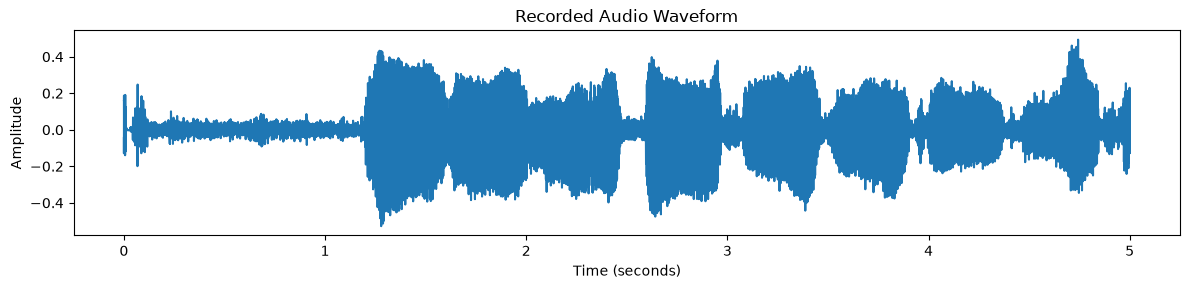

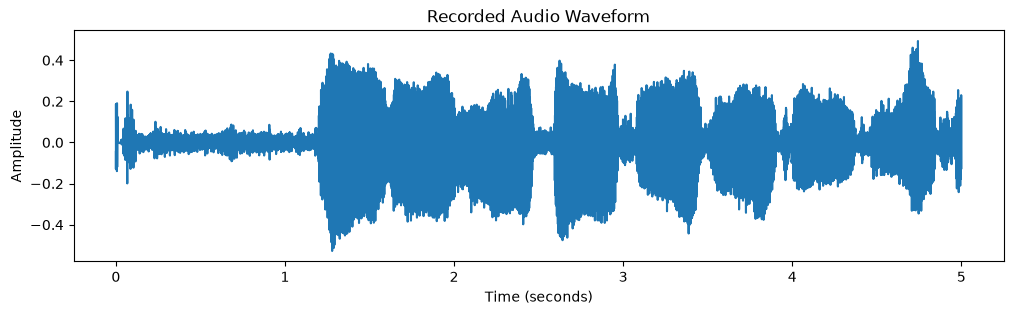

In [2]:
import sounddevice as sd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Recording settings
sr = 22050
duration = 5

print("Recording...")

audio = sd.rec(
    int(duration * sr),
    samplerate=sr,
    channels=1,
    dtype="float32"
)

sd.wait()

print("Recording complete!")

# Convert from (samples, 1) to (samples,)
x = audio[:, 0]

# --------------------------------------------------
# Playback recording
# --------------------------------------------------

print("Playing recording...")
display(Audio(x, rate=sr))

# --------------------------------------------------
# Plot waveform
# --------------------------------------------------

time = np.arange(len(x)) / sr

plt.figure(figsize=(12, 3))
plt.plot(time, x)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Recorded Audio Waveform")

plt.tight_layout()
plt.show()

time = np.arange(len(x)) / sr

plt.figure(figsize=(12, 3))
plt.plot(time, x)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Recorded Audio Waveform")
plt.show()

Dominant frequencies (Hz):
[450.4 449.8 767.4 451.  454.2]


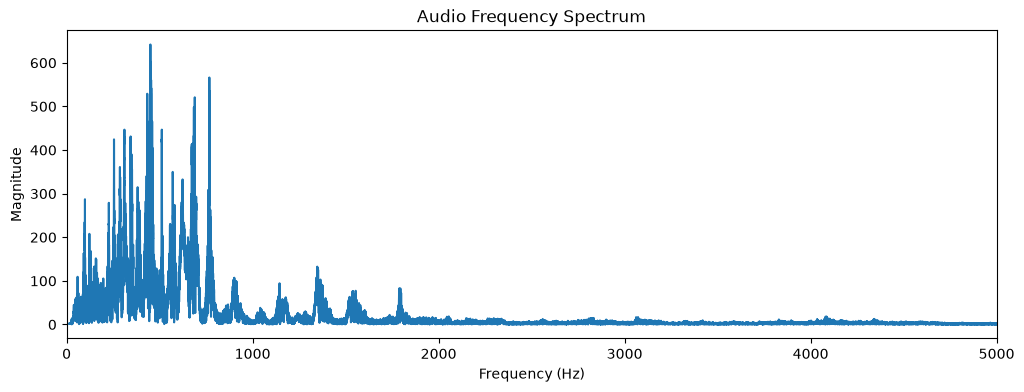

In [3]:
# Compute the Fourier transform
X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(len(x), d=1/sr)

# Magnitude spectrum
magnitude = np.abs(X)

# Find the five strongest nonzero frequency components
magnitude[0] = 0
indices = np.argsort(magnitude)[-5:][::-1]

dominant_freqs = freqs[indices]

print("Dominant frequencies (Hz):")
print(dominant_freqs)

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Audio Frequency Spectrum")
plt.xlim(0, 5000)
plt.show()

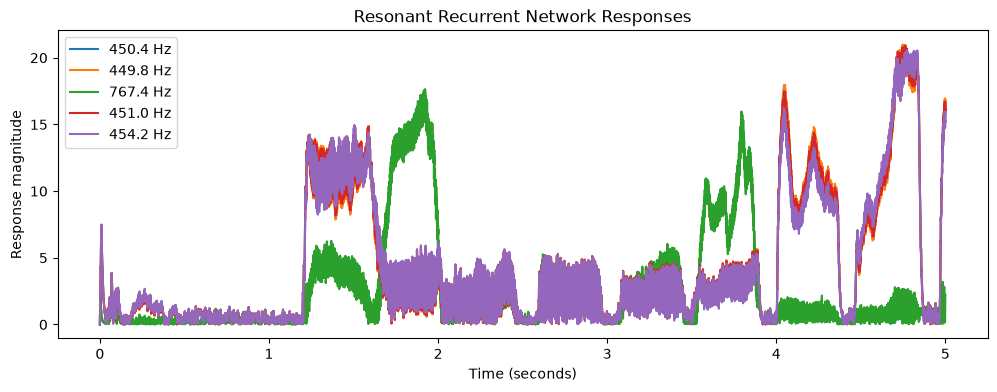

In [6]:
# Keep only plausible, positive frequencies
dominant_freqs = dominant_freqs[dominant_freqs > 0]

# Construct a two-dimensional oscillator for each frequency
r = 0.995
responses = []

for f in dominant_freqs:
    omega = 2 * np.pi * f / sr

    A = r * np.array([
        [np.cos(omega), -np.sin(omega)],
        [np.sin(omega),  np.cos(omega)]
    ])

    h = np.zeros((len(x), 2))

    for t in range(1, len(x)):
        h[t] = A @ h[t-1] + np.array([x[t], 0])

    # Oscillator activation magnitude
    response = np.linalg.norm(h, axis=1)
    responses.append(response)

responses = np.array(responses)

plt.figure(figsize=(12, 4))
for i, f in enumerate(dominant_freqs):
    plt.plot(time, responses[i], label=f"{f:.1f} Hz")

plt.xlabel("Time (seconds)")
plt.ylabel("Response magnitude")
plt.title("Resonant Recurrent Network Responses")
plt.legend()
plt.show()

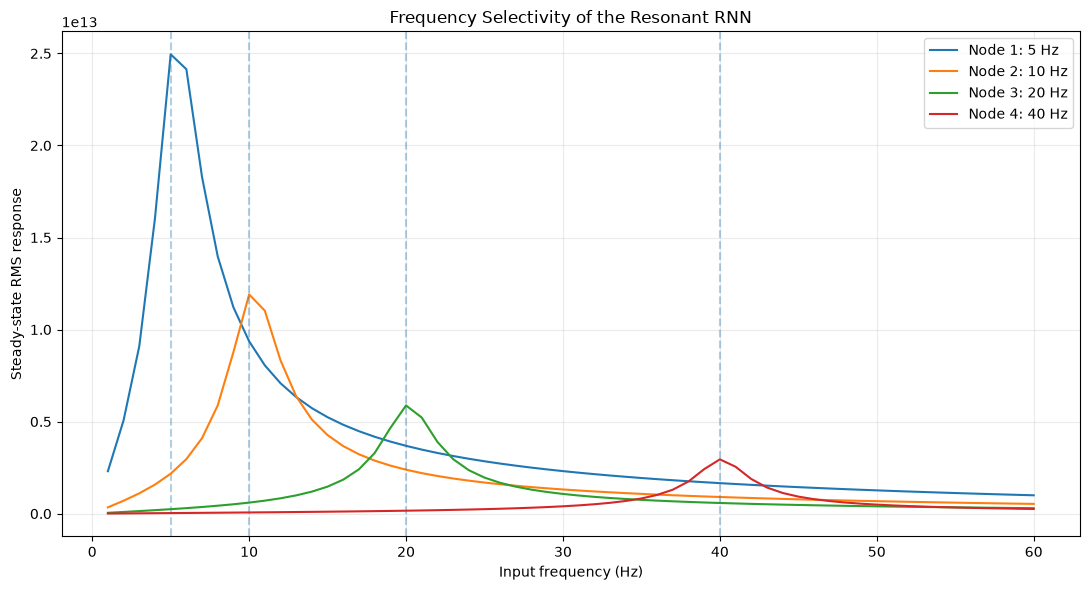

Node 1 (designed for 5 Hz): peak at 5 Hz, RMS response = 24952536528176.65234
Node 2 (designed for 10 Hz): peak at 10 Hz, RMS response = 11910132148129.97656
Node 3 (designed for 20 Hz): peak at 20 Hz, RMS response = 5877916576904.38086
Node 4 (designed for 40 Hz): peak at 40 Hz, RMS response = 2948070702216.31104


In [17]:

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Network configuration
# --------------------------------------------------

Fs = 1000
duration = 3.0
T = int(Fs * duration)
time = np.arange(T) / Fs

freqs = np.array([5, 10, 20, 40])
n_nodes = len(freqs)

r = 1.01
alpha1 = 2 * r * np.cos(2 * np.pi * freqs / Fs)
alpha2 = np.full(n_nodes, -r**2)

# Disable coupling for isolated oscillator tests
W = np.zeros((n_nodes, n_nodes))


# --------------------------------------------------
# 2. Simulate the network for one input frequency
# --------------------------------------------------

def run_rrn(u):
    x = np.zeros((n_nodes, len(u)))

    for t in range(2, len(u)):
        for k in range(n_nodes):
            x[k, t] = (
                alpha1[k] * x[k, t-1]
                + alpha2[k] * x[k, t-2]
                + u[t]
            )

    return x


# --------------------------------------------------
# 3. Sweep through input frequencies
# --------------------------------------------------

test_freqs = np.arange(1, 61, 1)
response_amplitudes = np.zeros((n_nodes, len(test_freqs)))

input_amplitude = 0.01

# Measure the final 1 second, after the initial transient
steady_start = int(2 * Fs)

for i, f_in in enumerate(test_freqs):

    # Known sinusoidal input
    u = input_amplitude * np.sin(2 * np.pi * f_in * time)

    # Run the network
    x = run_rrn(u)

    # Measure steady-state RMS amplitude
    for k in range(n_nodes):
        steady = x[k, steady_start:]
        response_amplitudes[k, i] = np.sqrt(
            np.mean(steady**2)
        )


# --------------------------------------------------
# 4. Plot frequency response
# --------------------------------------------------

plt.figure(figsize=(11, 6))

for k, f_node in enumerate(freqs):
    plt.plot(
        test_freqs,
        response_amplitudes[k],
        label=f"Node {k+1}: {f_node} Hz"
    )

    plt.axvline(f_node, linestyle="--", alpha=0.35)

plt.xlabel("Input frequency (Hz)")
plt.ylabel("Steady-state RMS response")
plt.title("Frequency Selectivity of the Resonant RNN")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. Report peak responses
# --------------------------------------------------

for k, f_node in enumerate(freqs):
    peak_idx = np.argmax(response_amplitudes[k])
    peak_freq = test_freqs[peak_idx]
    peak_response = response_amplitudes[k, peak_idx]

    print(
        f"Node {k+1} (designed for {f_node} Hz): "
        f"peak at {peak_freq} Hz, "
        f"RMS response = {peak_response:.5f}"
    )

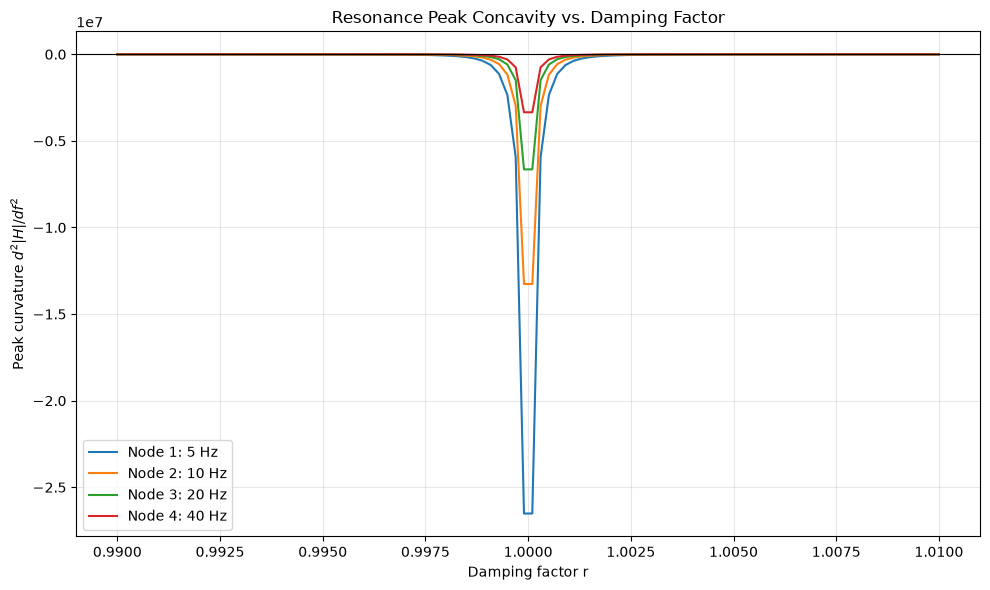

In [5]:

import numpy as np
import matplotlib.pyplot as plt

# Network configuration
Fs = 1000
freqs = np.array([5, 10, 20, 40])
r_values = np.linspace(0.99, 1.01, 100)

# Frequency offset used to estimate the second derivative
# A small offset approximates local curvature around each peak
df = 0.1  # Hz

def frequency_response(f, f0, r, Fs):
    """Magnitude response of a resonant node."""
    omega = 2 * np.pi * f / Fs
    omega0 = 2 * np.pi * f0 / Fs

    denominator_squared = (
        (1 + r**2 - 2*r*np.cos(omega - omega0))
        * (1 + r**2 - 2*r*np.cos(omega + omega0))
    )

    return 1 / np.sqrt(denominator_squared)

def peak_concavity(f0, r, Fs, df=0.1):
    """
    Estimate d²|H|/df² at the designed frequency f0.
    Negative curvature indicates a local maximum.
    """
    H_minus = frequency_response(f0 - df, f0, r, Fs)
    H_center = frequency_response(f0, f0, r, Fs)
    H_plus = frequency_response(f0 + df, f0, r, Fs)

    curvature = (H_plus - 2*H_center + H_minus) / df**2
    return curvature

# Compute concavity for every node and damping factor
concavities = np.zeros((len(freqs), len(r_values)))

for k, f0 in enumerate(freqs):
    for i, r in enumerate(r_values):
        concavities[k, i] = peak_concavity(f0, r, Fs, df)

# Plot raw curvature
plt.figure(figsize=(10, 6))

for k, f0 in enumerate(freqs):
    plt.plot(
        r_values,
        concavities[k],
        label=f"Node {k+1}: {f0} Hz"
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Damping factor r")
plt.ylabel(r"Peak curvature $d^2|H|/df^2$")
plt.title("Resonance Peak Concavity vs. Damping Factor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

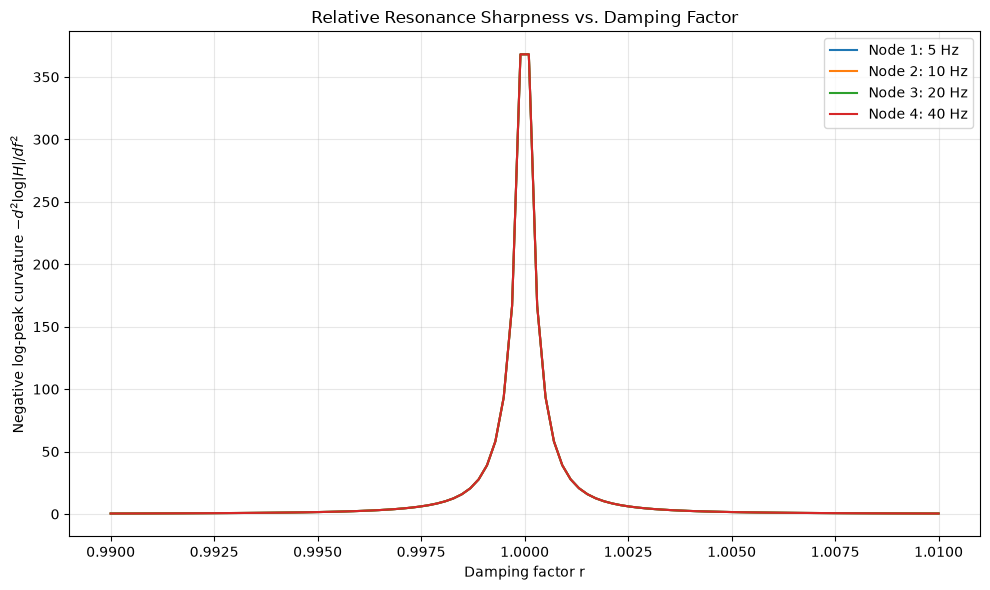

In [24]:

def log_peak_concavity(f0, r, Fs, df=0.1):
    H_minus = frequency_response(f0 - df, f0, r, Fs)
    H_center = frequency_response(f0, f0, r, Fs)
    H_plus = frequency_response(f0 + df, f0, r, Fs)

    return (
        np.log(H_plus)
        - 2*np.log(H_center)
        + np.log(H_minus)
    ) / df**2

log_concavities = np.zeros((len(freqs), len(r_values)))

for k, f0 in enumerate(freqs):
    for i, r in enumerate(r_values):
        log_concavities[k, i] = log_peak_concavity(
            f0, r, Fs, df
        )

plt.figure(figsize=(10, 6))

for k, f0 in enumerate(freqs):
    plt.plot(
        r_values,
        -log_concavities[k],
        label=f"Node {k+1}: {f0} Hz"
    )

plt.xlabel("Damping factor r")
plt.ylabel(r"Negative log-peak curvature $-d^2\log|H|/df^2$")
plt.title("Relative Resonance Sharpness vs. Damping Factor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()